In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier as knn

In [2]:
Data = 'data/data.csv'
df = pd.read_csv(Data, sep=';')

Data_X = df.drop(columns=['Target'])
Data_y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(Data_X, Data_y, test_size=0.2, random_state=42)

In [3]:
Knn_model = knn()


Knn_model.fit(X_train, y_train)
knn_y_pred = Knn_model.predict(X_test)

knn_Accuracy = accuracy_score(y_test, knn_y_pred)
print(f'K-Nearest Neighbour Accuracy: {knn_Accuracy * 100:.2f}%')

K-Nearest Neighbour Accuracy: 60.90%


In [4]:
RandomForest_model = RandomForestClassifier()

RandomForest_model.fit(X_train, y_train)
RandomForest_y_pred = RandomForest_model.predict(X_test)

RandomForest_Accuracy = accuracy_score(y_test, RandomForest_y_pred)
print(f'Random Forest Accuracy: {RandomForest_Accuracy * 100:.2f}%')

Random Forest Accuracy: 76.72%


In [23]:
# Feature selection
Data_X_features = 'data/data(Some features dropped).csv'
Data_X = pd.read_csv(Data_X_features)
Data_X = Data_X.drop(columns=['Target'])


X_train, X_test, y_train, y_test = train_test_split(Data_X, Data_y, test_size=0.2, random_state=42)

RandomForest_model = RandomForestClassifier()

RandomForest_model.fit(X_train, y_train)
RandomForest_y_pred = RandomForest_model.predict(X_test)

RandomForest_Accuracy = accuracy_score(y_test, RandomForest_y_pred)
print(f'Random Forest (Feature Selection) Accuracy: {RandomForest_Accuracy * 100:.2f}%')

Random Forest (Feature Selection) Accuracy: 75.37%


In [25]:
# Some Features added 
Data_X_features = 'data/data(Some features added).csv'
Data_X = pd.read_csv(Data_X_features)
Data_X = Data_X.drop(columns=['Target'])


X_train, X_test, y_train, y_test = train_test_split(Data_X, Data_y, test_size=0.2, random_state=42)

RandomForest_model = RandomForestClassifier()

RandomForest_model.fit(X_train, y_train)
RandomForest_y_pred = RandomForest_model.predict(X_test)

RandomForest_Accuracy = accuracy_score(y_test, RandomForest_y_pred)
print(f'Random Forest (Some features added) Accuracy: {RandomForest_Accuracy * 100:.2f}%')

Random Forest (Some features added) Accuracy: 76.61%


In [41]:
# Converted to binary data 
Data_X_features = 'data/Binary_data.csv'
Data_X = pd.read_csv(Data_X_features)
Data_y = Data_X['Target']
Data_X = Data_X.drop(columns=['Target'])


X_train, X_test, y_train, y_test = train_test_split(Data_X, Data_y, test_size=0.2, random_state=42)

RandomForest_model = RandomForestClassifier()

RandomForest_model.fit(X_train, y_train)
RandomForest_y_pred = RandomForest_model.predict(X_test)

RandomForest_Accuracy = accuracy_score(y_test, RandomForest_y_pred)
print(f'Random Forest (Binary data) Accuracy: {RandomForest_Accuracy * 100:.2f}%')

Random Forest (Binary data) Accuracy: 91.05%


In [40]:
Data_X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3630 entries, 0 to 3629
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Marital status                          3630 non-null   int64  
 1   Application mode                        3630 non-null   int64  
 2   Course                                  3630 non-null   int64  
 3   Previous qualification                  3630 non-null   int64  
 4   Previous qualification (grade)          3630 non-null   float64
 5   Mother's qualification                  3630 non-null   int64  
 6   Father's qualification                  3630 non-null   int64  
 7   Mother's occupation                     3630 non-null   int64  
 8   Father's occupation                     3630 non-null   int64  
 9   Admission grade                         3630 non-null   float64
 10  Debtor                                  3630 non-null   int64  
 11  Tu

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# Initialize the model with some 'Advanced' tuning
model_lgb = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    boosting_type='gbdt',
    random_state=42
)

# Train with early stopping to prevent overfitting
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='binary_logloss'
)

print(f"LightGBM Accuracy: {accuracy_score(y_test, model_lgb.predict(X_test)):.4f}")

              precision    recall  f1-score   support

     Dropout       0.92      0.84      0.88       277
    Graduate       0.90      0.95      0.93       449

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726



<Axes: >

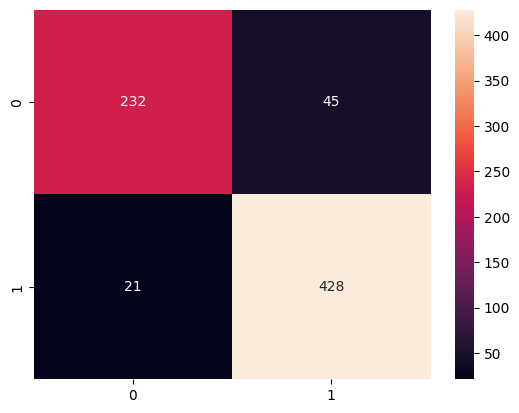

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(y_test, RandomForest_y_pred))

sns.heatmap(confusion_matrix(y_test, RandomForest_y_pred), annot=True, fmt='d')